In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")df.head()

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [24]:
#how many employees left the company
df['Attrition'].value_counts()
#Business Insight: Most employees stayed, while a smaller percentage left the company.

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [23]:
#Which department has highest employee attrition?
df.groupby('Department')['Attrition'].value_counts()
#Business Insight: Research & Development department had the highest employee attrition count, followed by Sales.

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

In [22]:
#Which gender shows higher employee attrition?
df.groupby('Gender')['Attrition'].value_counts()
#Business Insight: More male employees left the company than female employees.

Gender  Attrition
Female  No           501
        Yes           87
Male    No           732
        Yes          150
Name: count, dtype: int64

In [21]:
#Does overtime increase employee attrition?
df.groupby('OverTime')['Attrition'].value_counts()
#Business Insight: This indicates that overtime may be a major factor contributing to employee turnover.

OverTime  Attrition
No        No           944
          Yes          110
Yes       No           289
          Yes          127
Name: count, dtype: int64

In [20]:
#Which job roles have the highest employee attrition?
df.groupby('JobRole')['Attrition'].value_counts()
#Business Insight:Laboratory Technicians and Sales Executives showed the highest employee attrition among all job roles.

JobRole                    Attrition
Healthcare Representative  No           122
                           Yes            9
Human Resources            No            40
                           Yes           12
Laboratory Technician      No           197
                           Yes           62
Manager                    No            97
                           Yes            5
Manufacturing Director     No           135
                           Yes           10
Research Director          No            78
                           Yes            2
Research Scientist         No           245
                           Yes           47
Sales Executive            No           269
                           Yes           57
Sales Representative       No            50
                           Yes           33
Name: count, dtype: int64

In [19]:
#Which age groups show higher employee attrition?
df.groupby('Attrition')['Age'].mean()
#Business Insight: Employees who left the company were generally younger compared to employees who stayed.

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

In [26]:
#Does salary/income affect employee attrition?
df.groupby('Attrition')['MonthlyIncome'].mean()
#Business Insight: Employees who left the company had lower average monthly income compared to employees who stayed.

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [27]:
#Do employees with fewer working years leave the company more?
df.groupby('Attrition')['YearsAtCompany'].mean()
#Business Insight:Employees who left the company had fewer average years at the company compared to employees who stayed.

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

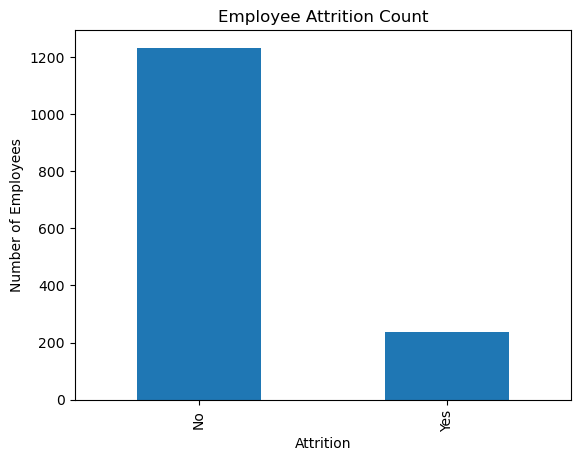

In [33]:
#Attrition Count Chart

df['Attrition'].value_counts().plot(kind='bar')

plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

#Business Insight: Most employees stayed with the company, while a smaller percentage left the organization.

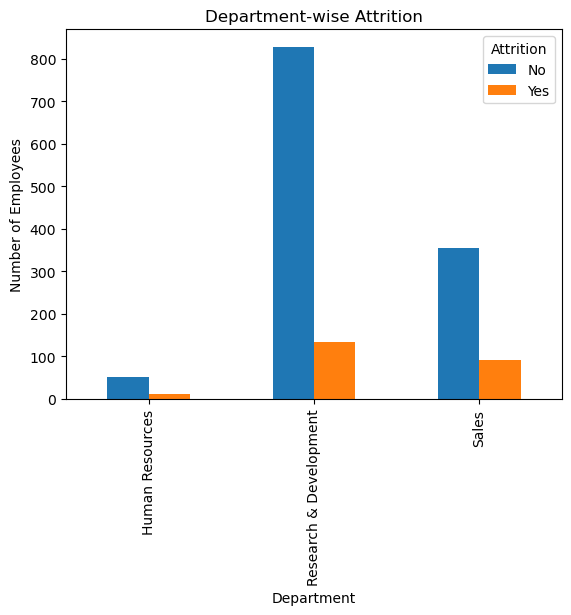

In [34]:
#Department-wise Attrition Chart

df.groupby('Department')['Attrition'].value_counts().unstack().plot(kind='bar')

plt.title('Department-wise Attrition')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.show()

#Business Insight: Research & Development and Sales departments showed higher employee attrition compared to Human Resources.

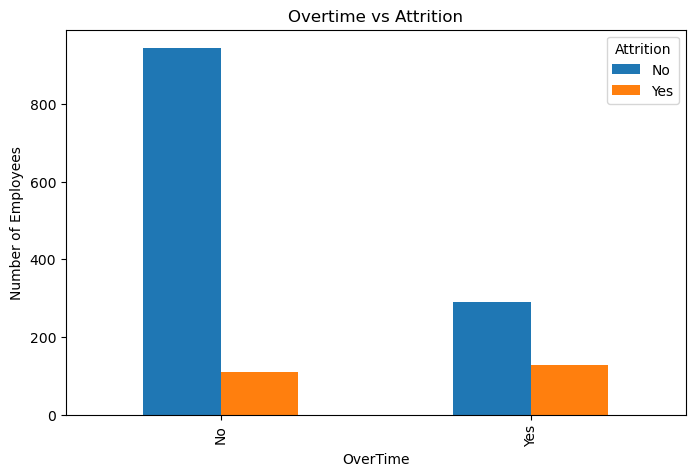

In [37]:
#Overtime vs Attrition Chart

df.groupby('OverTime')['Attrition'].value_counts().unstack().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Overtime vs Attrition')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')

plt.show()

#Business Insight: Employees working overtime showed significantly higher attrition compared to employees not working overtime.

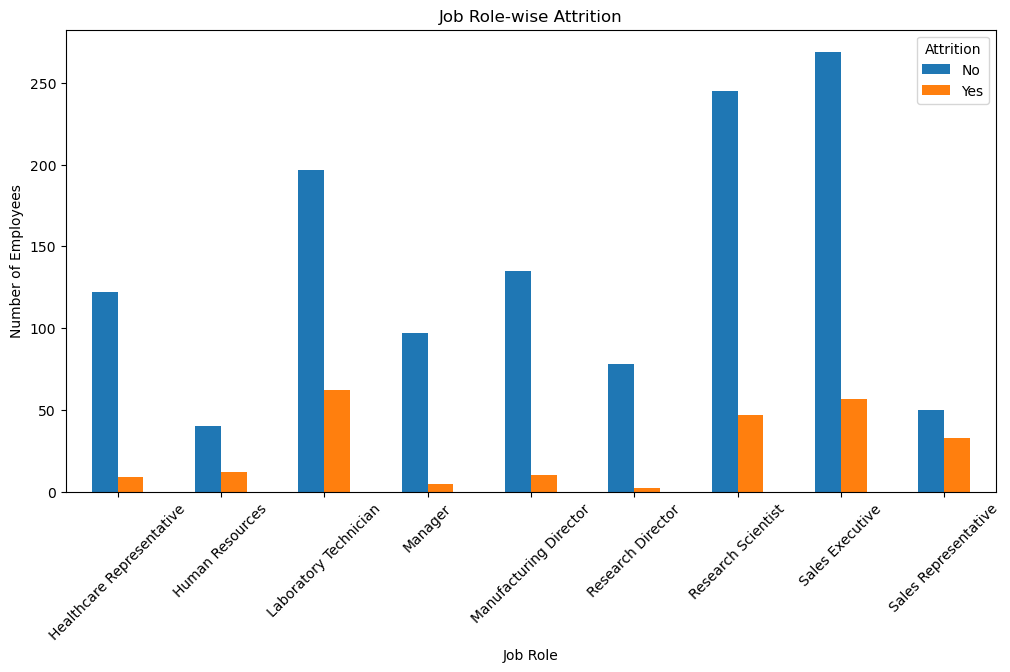

In [38]:
#Job Role-wise Attrition Chart

df.groupby('JobRole')['Attrition'].value_counts().unstack().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Job Role-wise Attrition')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')

plt.xticks(rotation=45)

plt.show()

#Business Insight: Laboratory Technicians and Sales Executives showed the highest employee attrition among all job roles.

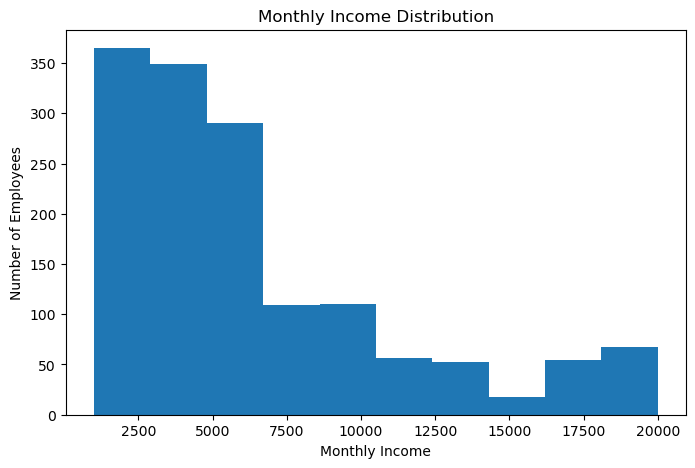

In [39]:
#Monthly Income Distribution Chart

df['MonthlyIncome'].plot(kind='hist', figsize=(8,5))

plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')

plt.show()

# Business Insight: Most employees fall within the lower to medium monthly income range, while fewer employees earn higher salaries.

In [40]:
df.to_csv('cleaned_hr_data.csv', index=False)